<a href="https://colab.research.google.com/github/Elnare05/Data-science/blob/main/Housing_Prices_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"elnaretagiyeva","key":"e0c7b99e402b219ca07392dbf8fce223"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#!/bin/bash
!kaggle datasets download yasserh/housing-prices-dataset

Dataset URL: https://www.kaggle.com/datasets/yasserh/housing-prices-dataset
License(s): CC0-1.0
  0% 0.00/4.63k [00:00<?, ?B/s]
100% 4.63k/4.63k [00:00<00:00, 15.4MB/s]


In [ ]:
!unzip /content/housing-prices-dataset.zip

Archive:  /content/housing-prices-dataset.zip
  inflating: Housing.csv             


In [ ]:
import pandas as pd
df = pd.read_csv('/content/Housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
df = pd.get_dummies(df, columns=['mainroad'], drop_first=True)

In [ ]:
df = pd.get_dummies(df, columns=['prefarea'], drop_first=True)

In [ ]:
df = pd.get_dummies(df, columns=['airconditioning'], drop_first=True)

In [ ]:
df = pd.get_dummies(df, columns=['hotwaterheating'], drop_first=True)

In [ ]:
df = pd.get_dummies(df, columns=['basement'], drop_first=True)

In [ ]:
df = pd.get_dummies(df, columns=['guestroom'], drop_first=True)

In [ ]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first = True)

In [ ]:
df

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,prefarea_yes,airconditioning_yes,hotwaterheating_yes,basement_yes,guestroom_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,True,True,False,False,False,False,False
1,12250000,8960,4,4,4,3,True,False,True,False,False,False,False,False
2,12250000,9960,3,2,2,2,True,True,False,False,True,False,True,False
3,12215000,7500,4,2,2,3,True,True,True,False,True,False,False,False
4,11410000,7420,4,1,2,2,True,False,True,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,True,False,False,False,True,False,False,True
541,1767150,2400,3,1,1,0,False,False,False,False,False,False,True,False
542,1750000,3620,2,1,1,0,True,False,False,False,False,False,False,True
543,1750000,2910,3,1,1,0,False,False,False,False,False,False,False,False


In [ ]:
df.columns.tolist()


['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'parking',
 'mainroad_yes',
 'prefarea_yes',
 'airconditioning_yes',
 'hotwaterheating_yes',
 'basement_yes',
 'guestroom_yes',
 'furnishingstatus_semi-furnished',
 'furnishingstatus_unfurnished']

In [ ]:
X = df.drop(columns = ['price'])
Y = df['price']


In [ ]:
num_cols=['area', 'bedrooms', 'bathrooms','stories','parking' ]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])


In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,prefarea_yes,airconditioning_yes,hotwaterheating_yes,basement_yes,guestroom_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,True,True,False,False,False,False,False
1,12250000,8960,4,4,4,3,True,False,True,False,False,False,False,False
2,12250000,9960,3,2,2,2,True,True,False,False,True,False,True,False
3,12215000,7500,4,2,2,3,True,True,True,False,True,False,False,False
4,11410000,7420,4,1,2,2,True,False,True,False,True,True,False,False


<Axes: xlabel='area', ylabel='price'>

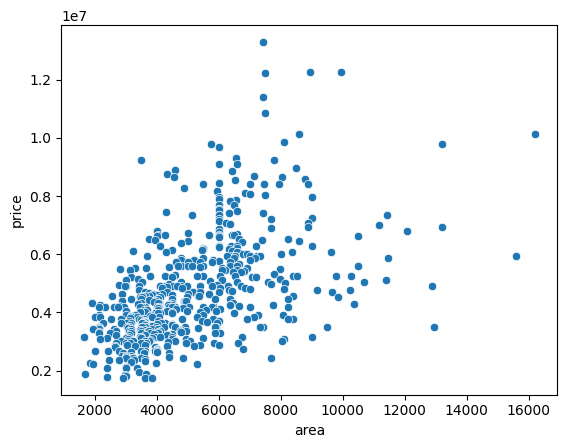

In [ ]:
sns.scatterplot(x='area', y='price', data=df)


In [ ]:
import seaborn as sns



<Axes: xlabel='bedrooms', ylabel='price'>

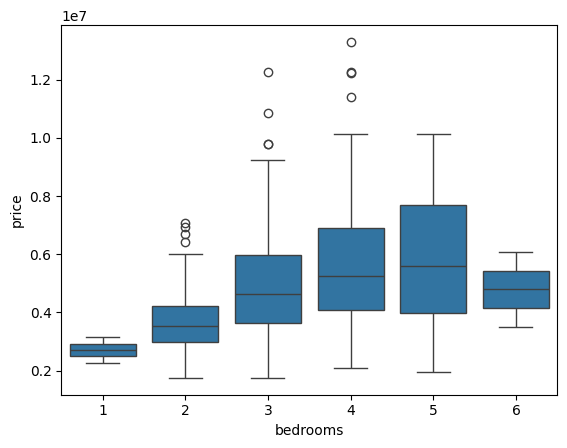

In [ ]:
sns.boxplot(x='bedrooms', y='price', data=df)


<Axes: xlabel='price', ylabel='Count'>

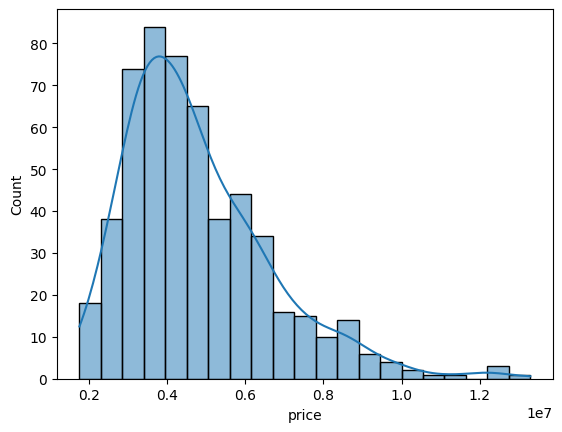

In [ ]:
sns.histplot(df['price'], kde=True)
